# Error-driven Payoff and Fairness

In [4]:
import sys
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import seaborn as sns
from pathlib import Path

from Utils.interaction import Performer
from Classes.cognitive_model_agents import FairnessM1, AttendanceM1

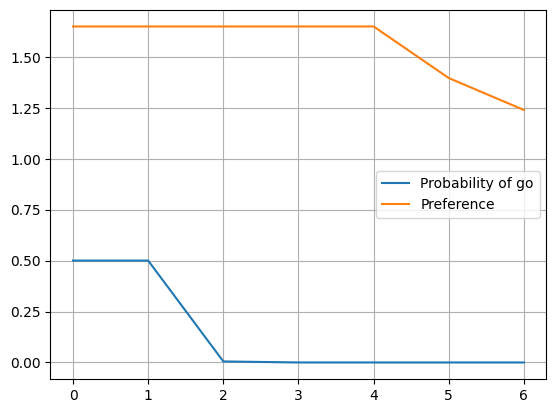

In [19]:
fixed_parameters = {
	"threshold":0.5,
	"num_agents":6,
}
free_parameters = {
	"learning_rate":0.2,
	"bias":1,
    "individual_threshold":0.5,
	"inverse_temperature":16,
}
agent = FairnessM1(
    free_parameters=free_parameters,
    fixed_parameters=fixed_parameters,
)
agent.number = 0
probabilities = []
powers = []
actions = [0, 0, 0, 0, 0, 1, 1]
for i, action in enumerate(actions):
    obs_state = [action] + [1] * (fixed_parameters['num_agents'] - 1)
    payoff = agent.payoff(action, obs_state)
    power_ = agent._get_G(obs_state)
    prob = agent.go_probability()
    probabilities.append(prob)
    powers.append(power_)
    if agent.debug:
        print("")
        print("="*60)
    agent.update(payoff, obs_state)

ax = sns.lineplot(
    x=range(len(probabilities)), y=probabilities, label="Probability of go"
)
sns.lineplot(
    x=range(len(powers)), y=powers, ax=ax, label="Preference"
)
ax.grid()
# ax.set_ylim(-1, 1.5)

In [5]:
fixed_parameters = {
	"threshold":0.5,
	"num_agents":6,
}
free_parameters = {
	"learning_rate": 0.2,
	"bias": 1,
    "individual_threshold": 0.4,
	"inverse_temperature":16
}
simulation_parameters = {
	'num_episodes':50,
	'num_rounds':100,
	'verbose':False
}

In [6]:
df_list = []
list_biases = [0, 0.5, 1]


for bias in list_biases:
    free_parameters['bias'] = bias
    df = Performer.sim(
        agent_class=FairnessM1,
        fixed_parameters=fixed_parameters,
        free_parameters=free_parameters,
        simulation_parameters=simulation_parameters,
    )
    df['bias'] = bias
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)

<Axes: xlabel='round', ylabel='score'>

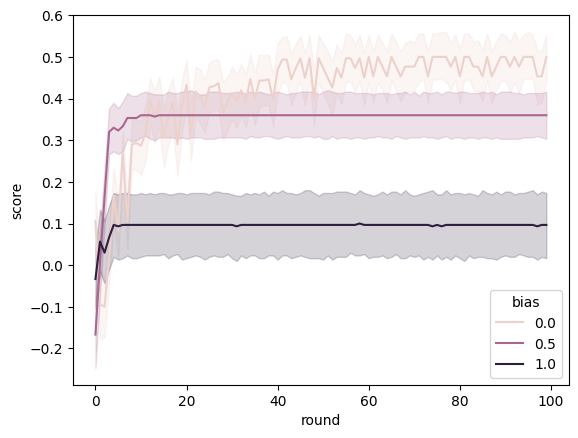

In [7]:
sns.lineplot(
    x='round', y='score',
    hue='bias',
    data=df,
)

In [5]:
from Utils.utils import GetMeasurements

gm = GetMeasurements(df, ['bounded_efficiency', 'gini_index'])
gm.columns.append('bias')
df_measures = gm.get_measurements()

<Axes: xlabel='bias', ylabel='gini_index'>

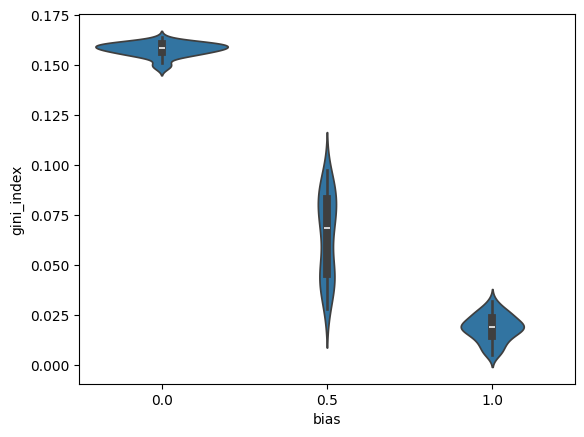

In [6]:
sns.violinplot(
    y='gini_index',
    x='bias',
    data=df_measures,
)

<Axes: xlabel='gini_index', ylabel='bounded_efficiency'>

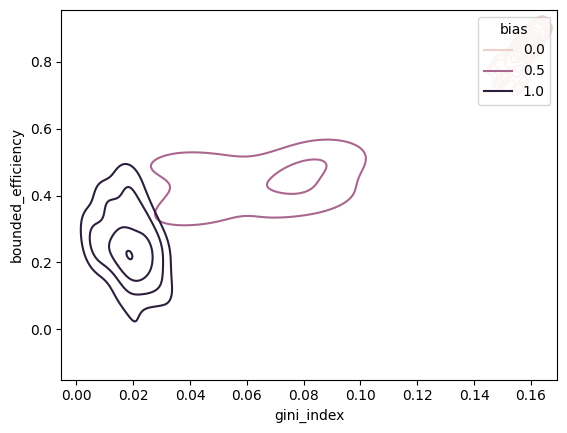

In [7]:
sns.kdeplot(
    x='gini_index', y='bounded_efficiency',
    hue='bias',
    data=df_measures,
)

In [12]:
fixed_parameters = {
	"threshold":0.5,
	"num_agents":6,
}
free_parameters = {
	"learning_rate": 0.2,
	"bias": 1,
    "individual_threshold": 0.8,
	"inverse_temperature":16
}
simulation_parameters = {
	'num_episodes':50,
	'num_rounds':100,
	'verbose':False
}

list_thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for threshold in list_thresholds:
    fixed_parameters['threshold'] = threshold
    df = Performer.sim(
        agent_class=FairnessM1,
        fixed_parameters=fixed_parameters,
        free_parameters=free_parameters,
        simulation_parameters=simulation_parameters,
    )
    df['threshold'] = threshold
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)

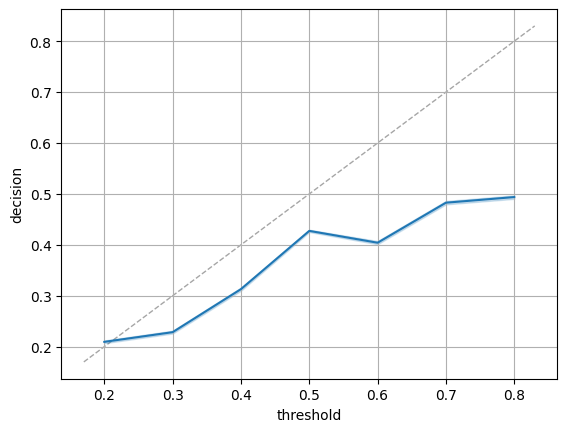

In [13]:
ax = sns.lineplot(
    x='threshold', y='decision',
    data=df,
)
ax.grid()
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
lo, hi = min(x0, y0), max(x1, y1)
ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=1, alpha=0.7, zorder=0)


In [11]:
from Classes.cognitive_model_agents import FairnessM1, FairnessM2, FairnessM3
from Utils.unit_tests import (
    test_bar_is_full, 
    test_bar_has_capacity,
    test_alternation
)

In [12]:
fixed_parameters = {
	"threshold":0.5,
	"num_agents":2,
}
free_parameters = {
	"learning_rate": 0.2,
    "bias": 0.5,
	"inverse_temperature":16
}

In [13]:
from pathlib import Path

image_folder_all = Path('../images/Fairness')
image_folder_all.mkdir(parents=True, exist_ok=True)
image_folder_M1 = Path('../images/Fairness/M1')
image_folder_M1.mkdir(parents=True, exist_ok=True)
image_folder_M2 = Path('../images/Fairness/M2')
image_folder_M2.mkdir(parents=True, exist_ok=True)
image_folder_M3 = Path('../images/Fairness/M3')
image_folder_M3.mkdir(parents=True, exist_ok=True)

1. [M1](#m1)
2. [M2](#m2)
3. [M3](#m3)

## M1 <a class="anchor" id="m1"></a>

In [14]:
agent = FairnessM1(
	fixed_parameters=fixed_parameters,
	free_parameters=free_parameters,
	n=0
)
agent.debug = True
test_bar_has_capacity(agent)


------------------------------------------------------------
Test bar has capacity
------------------------------------------------------------
Initial state: [0, 0]
---------- Round 0 ----------
Action preferences in state (0, 0): [0. 0.]
Action probabilities:
no go:0.5 ---- go:0.5
Chosen action: 0
State arrived: [0, 0]
Payoff action 0: 0
Average fairness: 1.6487212707001282
Payoff: 0
G observed for action 0 in state (0, 0) is: 0.8243606353500641
Learning rule:
Q[0] <- 0.0 + 0.2 * (0.8243606353500641 - 0.0)
Q[0] = 0.16487212707001284
---------- Round 1 ----------
Action preferences in state [0, 0]: [0.16487213 0.        ]
Action probabilities:
no go:0.9332646509438911 ---- go:0.06673534905610894
Chosen action: 0
State arrived: [0, 0]
Payoff action 0: 0
Average fairness: 1.6487212707001282
Payoff: 0
G observed for action 0 in state [0, 0] is: 0.8243606353500641
Learning rule:
Q[0] <- 0.16487212707001284 + 0.2 * (0.8243606353500641 - 0.16487212707001284)
Q[0] = 0.2967698287260231
-----

In [15]:
agent = FairnessM1(
	fixed_parameters=fixed_parameters,
	free_parameters=free_parameters,
	n=0
)
agent.debug = True
test_bar_is_full(agent)


------------------------------------------------------------
Test bar is full
------------------------------------------------------------
Initial state: [1, 1]
---------- Round 0 ----------
Action preferences in state (1, 1): [0. 0.]
Action probabilities:
no go:0.5 ---- go:0.5
Chosen action: 1
State arrived: [1, 1]
Payoff action 1: -1
Average fairness: 0.6065306597126334
Payoff: -1
G observed for action 1 in state (1, 1) is: -0.1967346701436833
Learning rule:
Q[1] <- 0.0 + 0.2 * (-0.1967346701436833 - 0.0)
Q[1] = -0.03934693402873666
---------- Round 1 ----------
Action preferences in state [1, 1]: [ 0.         -0.03934693]
Action probabilities:
no go:0.6523876332412172 ---- go:0.3476123667587828
Chosen action: 0
State arrived: [0, 1]
Payoff action 0: 0
Average fairness: 0.8464817248906141
Payoff: 0
G observed for action 0 in state [1, 1] is: 0.42324086244530706
Learning rule:
Q[0] <- 0.0 + 0.2 * (0.42324086244530706 - 0.0)
Q[0] = 0.08464817248906142
---------- Round 2 ----------
Act

In [16]:
agent = FairnessM1(
	fixed_parameters=fixed_parameters,
	free_parameters=free_parameters,
	n=0
)
agent.debug = True
test_alternation(agent)


------------------------------------------------------------
Test other player alternates
------------------------------------------------------------
Initial state: [0, 0]
---------- Round 0 ----------
Action preferences in state (0, 0): [0. 0.]
Action probabilities:
no go:0.5 ---- go:0.5
Chosen action: 0
State arrived: [0, 0]
Payoff action 0: 0
Average fairness: 1.6487212707001282
Payoff: 0
G observed for action 0 in state (0, 0) is: 0.8243606353500641
Learning rule:
Q[0] <- 0.0 + 0.2 * (0.8243606353500641 - 0.0)
Q[0] = 0.16487212707001284
---------- Round 1 ----------
Action preferences in state [0, 0]: [0.16487213 0.        ]
Action probabilities:
no go:0.9332646509438911 ---- go:0.06673534905610894
Chosen action: 0
State arrived: [0, 1]
Payoff action 0: 0
Average fairness: 1.6487212707001282
Payoff: 0
G observed for action 0 in state [0, 0] is: 0.8243606353500641
Learning rule:
Q[0] <- 0.16487212707001284 + 0.2 * (0.8243606353500641 - 0.16487212707001284)
Q[0] = 0.296769828726023

In [17]:
fixed_parameters = {
	"threshold":0.5,
	"num_agents":6,
}
free_parameters = {
	"learning_rate": 0.2,
	"bias": 0.5,
	"inverse_temperature":16
}
simulation_parameters = {
	'num_episodes':100,
	'num_rounds':1000,
	'verbose':False
}

In [18]:
from Utils.interaction import Performer

LaTeX_string = Performer.sweep(
    agent_class=FairnessM1,
    fixed_parameters=fixed_parameters,
    free_parameters=free_parameters,
    simulation_parameters=simulation_parameters,
    sweep_parameter='bias',
    values=[0, 0.2, 0.4, 0.6],
    image_folder=image_folder_M1,
    measures=['conditional_entropy', 'entropy', 'efficiency', 'inequality']
)

Running models for each bias:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

---

## M2 <a class="anchor" id="m2"></a>

In [ ]:
fixed_parameters = {
	"threshold":0.5,
	"num_agents":2,
}
free_parameters = {
	"learning_rate": 0.2,
	"bias": 0.5,
	"inverse_temperature":16
}
agent = FairnessM2(
	fixed_parameters=fixed_parameters,
	free_parameters=free_parameters,
	n=0
)
agent.debug = True
test_bar_has_capacity(agent)


------------------------------------------------------------
Test bar has capacity
------------------------------------------------------------
Initial state: [0, 0]
---------- Round 0 ----------
Action preferences in state (0, 0): [0. 0.]
Action probabilities:
no go:0.5 ---- go:0.5
Chosen action: 1
State arrived: [1, 0]
Payoff action 1: 1
Average fairness: 1.0
Payoff: 1
G observed for action 1 in state (0, 0) is: 1.0
Learning rule:
Q[(0, 0), 1] <- 0.0 + 0.2 * (1.0 - 0.0)
Q[(0, 0), 1] = 0.2
---------- Round 1 ----------
Action preferences in state [1, 0]: [0. 0.]
Action probabilities:
no go:0.5 ---- go:0.5
Chosen action: 1
State arrived: [1, 0]
Payoff action 1: 1
Average fairness: 0.8464817248906141
Payoff: 1
G observed for action 1 in state [1, 0] is: 0.923240862445307
Learning rule:
Q[(1, 0), 1] <- 0.0 + 0.2 * (0.923240862445307 - 0.0)
Q[(1, 0), 1] = 0.1846481724890614
---------- Round 2 ----------
Action preferences in state [1, 0]: [0.         0.18464817]
Action probabilities:
no 

In [ ]:
agent = FairnessM2(
	fixed_parameters=fixed_parameters,
	free_parameters=free_parameters,
	n=0
)
agent.debug = True
test_bar_is_full(agent)


------------------------------------------------------------
Test bar is full
------------------------------------------------------------
Initial state: [1, 1]
---------- Round 0 ----------
Action preferences in state (1, 1): [0. 0.]
Action probabilities:
no go:0.5 ---- go:0.5
Chosen action: 1
State arrived: [1, 1]
Payoff action 1: -1
Average fairness: 0.6065306597126334
Payoff: -1
G observed for action 1 in state (1, 1) is: -0.1967346701436833
Learning rule:
Q[(1, 1), 1] <- 0.0 + 0.2 * (-0.1967346701436833 - 0.0)
Q[(1, 1), 1] = -0.03934693402873666
---------- Round 1 ----------
Action preferences in state [1, 1]: [ 0.         -0.03934693]
Action probabilities:
no go:0.6523876332412172 ---- go:0.3476123667587828
Chosen action: 0
State arrived: [0, 1]
Payoff action 0: 0
Average fairness: 0.8464817248906141
Payoff: 0
G observed for action 0 in state [1, 1] is: 0.42324086244530706
Learning rule:
Q[(1, 1), 0] <- 0.0 + 0.2 * (0.42324086244530706 - 0.0)
Q[(1, 1), 0] = 0.08464817248906142
-

In [ ]:
agent = FairnessM2(
	fixed_parameters=fixed_parameters,
	free_parameters=free_parameters,
	n=0
)
agent.debug = True
test_alternation(agent)


------------------------------------------------------------
Test other player alternates
------------------------------------------------------------
Initial state: [0, 0]
---------- Round 0 ----------
Action preferences in state (0, 0): [0. 0.]
Action probabilities:
no go:0.5 ---- go:0.5
Chosen action: 1
State arrived: [1, 0]
Payoff action 1: 1
Average fairness: 1.0
Payoff: 1
G observed for action 1 in state (0, 0) is: 1.0
Learning rule:
Q[(0, 0), 1] <- 0.0 + 0.2 * (1.0 - 0.0)
Q[(0, 0), 1] = 0.2
---------- Round 1 ----------
Action preferences in state [1, 0]: [0. 0.]
Action probabilities:
no go:0.5 ---- go:0.5
Chosen action: 1
State arrived: [1, 1]
Payoff action 1: -1
Average fairness: 0.8464817248906141
Payoff: -1
G observed for action 1 in state [1, 0] is: -0.07675913755469294
Learning rule:
Q[(1, 0), 1] <- 0.0 + 0.2 * (-0.07675913755469294 - 0.0)
Q[(1, 0), 1] = -0.015351827510938588
---------- Round 2 ----------
Action preferences in state [1, 1]: [0. 0.]
Action probabilities:
n

In [ ]:
fixed_parameters = {
	"threshold":0.5,
	"num_agents":6,
}
free_parameters = {
	"learning_rate": 0.2,
	"bias": 0.5,
	"inverse_temperature":16
}
simulation_parameters = {
	'num_episodes':100,
	'num_rounds':100,
	'verbose':False
}

In [ ]:
from Utils.interaction import Performer

LaTeX_string = Performer.sweep(
    agent_class=FairnessM2,
    fixed_parameters=fixed_parameters,
    free_parameters=free_parameters,
    simulation_parameters=simulation_parameters,
    sweep_parameter='bias',
    values=[0, 0.2, 0.4, 0.6],
    image_folder=image_folder_M2,
    measures=['efficiency', 'inequality', 'entropy', 'conditional_entropy']
)

Running models for each bias:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Plotting efficiency...
Plot saved to ../images/Fairness/M2/efficiency_bias.png
Plotting inequality...
Plot saved to ../images/Fairness/M2/inequality_bias.png
Plotting entropy...
Plot saved to ../images/Fairness/M2/entropy_bias.png
Plotting conditional_entropy...
Plot saved to ../images/Fairness/M2/conditional_entropy_bias.png


---

## M3 <a class="anchor" id="m3"></a>

In [ ]:
fixed_parameters = {
	"threshold":0.5,
	"num_agents":2,
}
free_parameters = {
	"learning_rate": 0.2,
	"bias": 0.5,
	"inverse_temperature":16
}
agent = FairnessM3(
	fixed_parameters=fixed_parameters,
	free_parameters=free_parameters,
	n=0
)
agent.debug = True
test_bar_has_capacity(agent)


------------------------------------------------------------
Test bar has capacity
------------------------------------------------------------
Initial state: [0, 0]
---------- Round 0 ----------
Action preferences in state (0, 0): [0. 0.]
Action probabilities:
no go:0.5 ---- go:0.5
Chosen action: 0
State arrived: [0, 0]
Payoff action 0: 0
Average fairness: 1.6487212707001282
Payoff: 0
G observed for action 0 in state (0, 0) is: 0.8243606353500641
Learning rule:
Q[(0, 0),0] <- 0.0 + 0.2 * (0.8243606353500641 - 0.0)
Q[(0, 0),0] = 0.16487212707001284
---------- Round 1 ----------
Action preferences in state [0, 0]: [0.16487213 0.        ]
Action probabilities:
no go:0.9332646509438911 ---- go:0.06673534905610894
Chosen action: 0
State arrived: [0, 0]
Payoff action 0: 0
Average fairness: 1.6487212707001282
Payoff: 0
G observed for action 0 in state [0, 0] is: 0.8243606353500641
Learning rule:
Q[[0, 0],0] <- 0.16487212707001284 + 0.2 * (0.8243606353500641 - 0.16487212707001284)
Q[[0, 0],0

In [ ]:
agent = FairnessM3(
	fixed_parameters=fixed_parameters,
	free_parameters=free_parameters,
	n=0
)
agent.debug = True
test_bar_is_full(agent)


------------------------------------------------------------
Test bar is full
------------------------------------------------------------
Initial state: [1, 1]
---------- Round 0 ----------
Action preferences in state (1, 1): [0. 0.]
Action probabilities:
no go:0.5 ---- go:0.5
Chosen action: 0
State arrived: [0, 1]
Payoff action 0: 0
Average fairness: 1.0
Payoff: 0
G observed for action 0 in state (1, 1) is: 0.5
Learning rule:
Q[(1, 1),0] <- 0.0 + 0.2 * (0.5 - 0.0)
Q[(1, 1),0] = 0.1
---------- Round 1 ----------
Action preferences in state [0, 1]: [0. 0.]
Action probabilities:
no go:0.5 ---- go:0.5
Chosen action: 0
State arrived: [0, 1]
Payoff action 0: 0
Average fairness: 1.181360412865646
Payoff: 0
G observed for action 0 in state [0, 1] is: 0.590680206432823
Learning rule:
Q[[0, 1],0] <- 0.0 + 0.2 * (0.590680206432823 - 0.0)
Q[[0, 1],0] = 0.11813604128656462
---------- Round 2 ----------
Action preferences in state [0, 1]: [0.11813604 0.        ]
Action probabilities:
no go:0.8687

In [ ]:
agent = FairnessM3(
	fixed_parameters=fixed_parameters,
	free_parameters=free_parameters,
	n=0
)
agent.debug = True
test_alternation(agent)


------------------------------------------------------------
Test other player alternates
------------------------------------------------------------
Initial state: [0, 0]
---------- Round 0 ----------
Action preferences in state (0, 0): [0. 0.]
Action probabilities:
no go:0.5 ---- go:0.5
Chosen action: 1
State arrived: [1, 0]
Payoff action 1: 1
Average fairness: 1.0
Payoff: 1
G observed for action 1 in state (0, 0) is: 1.0
Learning rule:
Q[(0, 0),1] <- 0.0 + 0.2 * (1.0 - 0.0)
Q[(0, 0),1] = 0.2
---------- Round 1 ----------
Action preferences in state [1, 0]: [0. 0.]
Action probabilities:
no go:0.5 ---- go:0.5
Chosen action: 1
State arrived: [1, 1]
Payoff action 1: -1
Average fairness: 0.8464817248906141
Payoff: -1
G observed for action 1 in state [1, 0] is: -0.07675913755469294
Learning rule:
Q[[1, 0],1] <- 0.0 + 0.2 * (-0.07675913755469294 - 0.0)
Q[[1, 0],1] = -0.015351827510938588
---------- Round 2 ----------
Action preferences in state [1, 1]: [0. 0.]
Action probabilities:
no go

In [ ]:
fixed_parameters = {
	"threshold":0.5,
	"num_agents":6,
}
free_parameters = {
	"learning_rate": 0.2,
	"bias": 0.5,
	"inverse_temperature":16
}
simulation_parameters = {
	'num_episodes':100,
	'num_rounds':1000,
	'verbose':False
}

In [ ]:
from Utils.interaction import Performer

LaTeX_string = Performer.sweep(
    agent_class=FairnessM3,
    fixed_parameters=fixed_parameters,
    free_parameters=free_parameters,
    simulation_parameters=simulation_parameters,
    sweep_parameter='bias',
    values=[0, 0.2, 0.4, 0.6],
    image_folder=image_folder_M3,
    measures=['efficiency', 'inequality', 'entropy', 'conditional_entropy']
)

Running models for each bias:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Plotting efficiency...
Plot saved to ../images/Fairness/M3/efficiency_bias.png
Plotting inequality...
Plot saved to ../images/Fairness/M3/inequality_bias.png
Plotting entropy...
Plot saved to ../images/Fairness/M3/entropy_bias.png
Plotting conditional_entropy...
Plot saved to ../images/Fairness/M3/conditional_entropy_bias.png


---

In [ ]:
from Utils.interaction import Performer

fixed_parameters = {
	"threshold":0.5,
	"num_agents":6,
}
free_parameters = {
	"learning_rate": 0.2,
	"bias": 0.3,
	"inverse_temperature":16
}
simulation_parameters = {
	'num_episodes':100,
	'num_rounds':1000,
	'verbose':False
}

list_dicts = [
    {
        'agent_class': FairnessM1,
        'fixed_parameters': fixed_parameters,
        'free_parameters': free_parameters,
        'simulation_parameters': simulation_parameters,
        'seed': 7
    },
    {
        'agent_class': FairnessM2,
        'fixed_parameters': fixed_parameters,
        'free_parameters': free_parameters,
        'simulation_parameters': simulation_parameters,
        'seed': 9
    },
    {
        'agent_class': FairnessM3,
        'fixed_parameters': fixed_parameters,
        'free_parameters': free_parameters,
        'simulation_parameters': simulation_parameters,
        'seed': 0
    }
]

In [ ]:
#-------------------------------
# Create plots
#-------------------------------
perf = Performer.simple_vs(
    list_dicts=list_dicts,
    image_folder=image_folder_all,
    measures=['efficiency', 'inequality', 'entropy', 'conditional_entropy'],
    kwargs={
        'T': 20,
        'model_names': {
            'Attendance-M1-7': 'M1',
            'Attendance-M2-9': 'M2',
            'Attendance-M3-0': 'M3'
        },
        'figsize': (3.5, 3)
    }
)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

ValueError: No objects to concatenate

---

In [ ]:
from Utils.interaction import Performer

fixed_parameters = {
	"threshold":0.5,
	"num_agents":6,
}
free_parameters = {
	"learning_rate": 0.2,
	"bias": 0.3,
	"inverse_temperature":16
}
simulation_parameters = {
	'num_episodes':1,
	'num_rounds':1000,
	'verbose':False
}

In [ ]:
LaTeX_string = Performer.simple_run(
    agent_class=FairnessM1,
    fixed_parameters=fixed_parameters,
    free_parameters=free_parameters,
    simulation_parameters=simulation_parameters,
    image_folder=image_folder_M1,
    measures=['render']
)

In [ ]:
LaTeX_string = Performer.simple_run(
    agent_class=FairnessM2,
    fixed_parameters=fixed_parameters,
    free_parameters=free_parameters,
    simulation_parameters=simulation_parameters,
    image_folder=image_folder_M2,
    measures=['render']
)

In [ ]:
LaTeX_string = Performer.simple_run(
    agent_class=FairnessM3,
    fixed_parameters=fixed_parameters,
    free_parameters=free_parameters,
    simulation_parameters=simulation_parameters,
    image_folder=image_folder_M3,
    measures=['render']
)